# Esame Laboratorio di Programmazione II - 27/06/2025


## Esercizio 1

Crea un array NumPy con i prezzi (in euro) di 5 libri: **14.99, 22.50, 9.75, 18.00, 31.20, 12.80, 24.90, 8.40, 19.99, 27.30**

1. Calcola il prezzo medio dei libri
2. Seleziona i libri con un prezzo maggiore della media.
3. Crea un nuovo array che applica uno sconto del 10% solo ai libri che costano più della media.

#### LEGGENDA

- **np.array([...])** -> Crea un ***array*** Numpy da una lista di numeri

- **.mean()** -> Calcola la ***media aritmetica*** di tutti gli elementi

- **array > valore** -> ***Confronto vettoriale***: restituisce un array di booleani (True/False)

- **array[mask]** -> ***Indicizzazione booleana***: estrae solo gli elementi dove mask è True

- **.copy()** -> Crea una copia indipendente dell’array (per non modificare l’originale)

- array[mask] *= 0.9 -> Applica lo sconto del 10% solo agli elementi selezionati dalla maschera

- **np.round(array, 2)** -> Arrotonda i valori a 2 decimali per una stampa pulita

In [1]:
import numpy as np

# 1. Creo l'arry dei prezzi
prezzi = np.array([14.99, 22.50, 9.75, 18.00, 31.20, 12.80, 24.90, 8.40, 19.99, 27.30])
print("Prezzi originali:", prezzi)

# 2. Calcolo il prezzo medio
media = prezzi.mean()
print(f"Prezzo medio: {media:.2f}")

# 3. Seleziono i libri con prezzo maggiore della media
media_maggiore = prezzi[prezzi > media]
print("Libri sopra la media:", media_maggiore)

# 4. Eseguo lo sconto del 10% sui libri che costano piu della media
prezzi_scontati = prezzi.copy()
prezzi_scontati[prezzi > media] *= 0.9
print("Prezzi dopo sconto:", np.round(prezzi_scontati, 2))


Prezzi originali: [14.99 22.5   9.75 18.   31.2  12.8  24.9   8.4  19.99 27.3 ]
Prezzo medio: 18.98
Libri sopra la media: [22.5  31.2  24.9  19.99 27.3 ]
Prezzi dopo sconto: [14.99 20.25  9.75 18.   28.08 12.8  22.41  8.4  17.99 24.57]


## Esercizio 2

Simula 1000 lanci di una moneta che ad ogni lancio ha il doppio di probabilità di risultare croce invece che testa. Ogni lancio è rappresentato da 1 (testa) o 0 (croce).

1. Crea un array NumPy contenente i risultati.
2. Calcola la proporzione di teste dopo ogni 50 lanci cumulativi.
3. Crea un grafico della proporzione cumulativa nel tempo (dopo 50 lanci, dopo 100, dopo 150,...).

#### LEGGENDA

- **np.random.choice([0,1], size=n, p=[2/3,1/3])** -> Genera n lanci: ***0=croce (prob 2/3)***, ***1=testa (1/3)***

- **lanci[:n]** -> Slicing: prende i primi ***n*** elementi dell'array (utile per il cumulativo)

- **.mean()** -> Calcola la media; su array di 0/1 la media equivale alla proporzione di 1 (teste)

- **list(range(50, 1001, 50))** -> Crea i punti 50, 100, 150, ..., 1000

- **plt.plot(x, y, marker='o')** -> Grafico a linee con pallini sui punti

- **plt.axhline(y=1/3, color='r', linestyle='--')** -> Linea orizzontale tratteggiata (probabilità teorica)

- **plt.xlabel(), plt.ylabel(), plt.title()** -> Etichette e titolo

- **plt.grid(True), plt.legend()** -> Griglia e legenda

- **plt.show()** -> Visualizza il grafico

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# PUNTO 1: Simulo 1000 lanci (0 = Croce, 1 = Testa) con P(croce) = 2/3, P(test) = 1/3
n_lanci = 1000
lanci = np.random.choice([0, 1], size=n_lanci, p=[2/3, 1/3])
print("Primi 20 lanci (0=croce, 1=testa):", lanci[:20].tolist())

Primi 20 lanci (0=croce, 1=testa): [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1]


In [10]:
# PUNTO 2: Calcolo la proporzione di teste dopo ogni 50 lanci
step_lanci = list(range(50, n_lanci + 1, 50))   # [50, 100, 150, ..., 1000]
proporzioni = []

for n in step_lanci:
    sottogruppo = lanci[:n]                 # Primi n lanci
    media_corrente = sottogruppo.mean()     # Proporzione di teste (perché media di 0/1)
    proporzioni.append(media_corrente)

print("\nProporzione di teste dopo ogni 50 lanci:")
print(np.round(proporzioni, 3).tolist())


Proporzione di teste dopo ogni 50 lanci:
[0.34, 0.33, 0.333, 0.325, 0.324, 0.313, 0.329, 0.322, 0.313, 0.308, 0.298, 0.31, 0.314, 0.317, 0.315, 0.321, 0.326, 0.331, 0.331, 0.325]


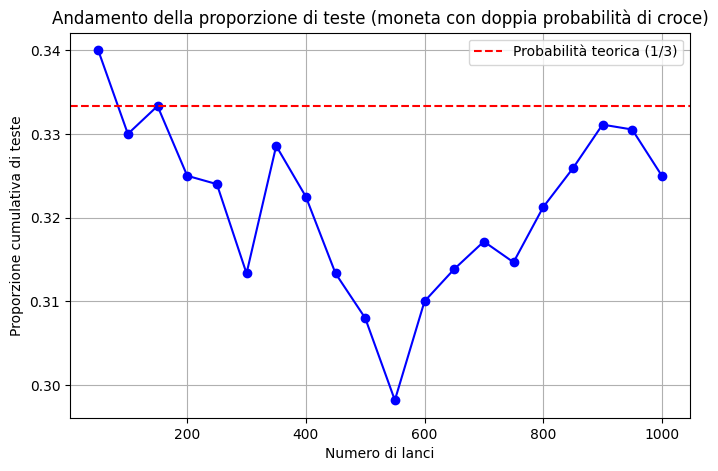

In [11]:
# PUNTO 3. Grafico della proporzione cumulativa
plt.figure(figsize=(8,5))
plt.plot(step_lanci, proporzioni, marker='o', linestyle='-', color='b')
plt.axhline(y=1/3, color='r', linestyle='--', label='Probabilità teorica (1/3)')
plt.xlabel("Numero di lanci")
plt.ylabel("Proporzione cumulativa di teste")
plt.title("Andamento della proporzione di teste (moneta con doppia probabilità di croce)")
plt.grid(True)
plt.legend()
plt.show()

## Esercizio 3

Crea una funzione di nome **mat_normalizzata** che prende come input una matrice e ritorna la matrice normalizzata.

La funzione deve quindi:
1. Calcolare la media e la deviazione standard della matrice.
2. Normalizzare la matrice sottraendo la media e dividendo per la deviazione standard.

Testa La funzione con un array NumPy 6x10 con numeri campionati da una distribuzione normale (media=5, std=2).

#### LEGGENDA

- **np.random.normal(loc=5, scale=2, size=(6,10))** -> Genera una matrice 6x10 con distribuzione normale (media 5, dev std 2)

- **np.mean(matrice)** -> Calcola la media di tutti gli elementi

- **np.std(matrice)** -> Calcola la deviazione standard di tutti gli elementi

- **(matrice - media) / std** -> Normalizzazione: sottrae la media e divide per la deviazione standard

- **return** -> Restituisce il risultato

In [15]:
import numpy as np

# PUNTO 1. Calcolo la media e la deviazione standard
def mat_normalizzata(matrice):
    media = np.mean(matrice)        # Calcolo media
    std = np.std(matrice)           # Calcolo deviazione standard

    # Normalizzo: (x - media) / std
    normalizzata = (matrice - media) / std
    return normalizzata

# PUNTO 2. Test
dati = np.random.normal(loc=5, scale=2, size=(6, 10))
print("Matrice originale (prime 2 righe):\n", dati[:2], "\n")

norm = mat_normalizzata(dati)
print("Matrice normalizzata (prime 2 righe):\n", norm[:2], "\n")
print("Media della normalizzata:", np.mean(norm), "\n")
print("Deviazione standard della normalizzata:", np.std(norm))

Matrice originale (prime 2 righe):
 [[5.33741004 7.19529613 6.74656617 2.4575536  5.80199842 6.97993615
  4.1392153  5.1121784  3.10123944 4.59218546]
 [3.97220355 7.53818201 4.05583556 5.21735177 1.37405699 7.67149515
  6.64977742 7.21198122 5.23429225 8.40153767]] 

Matrice normalizzata (prime 2 righe):
 [[-0.02129745  0.88121332  0.66323245 -1.42025375  0.20438701  0.77659727
  -0.60334802 -0.13070888 -1.1075686  -0.38330738]
 [-0.68447781  1.047778   -0.64385164 -0.07961851 -1.94658708  1.11253791
   0.6162151   0.88931848 -0.07138928  1.46717281]] 

Media della normalizzata: -4.810966440042345e-17 

Deviazione standard della normalizzata: 1.0


## Esercizio 4

Utilizza il dataset `books.csv`.

1. **Crea una nuova colonna** chiamata `engagement_score`, definita come:

   $$
   \texttt{engagement\_score} = \texttt{average\_rating} \times \log_{10}(1 + \texttt{ratings\_count})
   $$

   *(Un indicatore che tiene conto sia della qualità (valutazione media), sia della quantità di voti. Il logaritmo serve ad attenuare l'effetto dei libri estremamente popolari.)*

2. Trova il **libro con il valore massimo** di `engagement_score`.

3. **Filtra i libri** con una valutazione media (`average_rating`) **maggiore di 4.5**.

4. **Crea un grafico a barre** con i 10 libri con il valore più alto di `engagement_score`.

5. **Crea un grafico a linee** della `average_rating`, ordinando i libri per `ratings_count` crescente.


#### LEGGENDA

- **pd.read_csv('file.csv')** -> Legge il CSV in un DataFrame

- **df.head()** -> Mostra le prime righe

- **np.log10(x)** -> Logaritmo in base 10

- **df['nuova'] = df['col1'] * np.log10(1 + df['col2'])** -> Crea nuova colonna con operazione vettoriale

- **df.loc[df['col'].idxmax()]** -> Trova la riga con il valore massimo in una colonna

- **df[df['col'] > valore]** -> Filtra le righe

- **df.nlargest(n, 'col')** -> Prende le n righe con i valori più alti di una colonna

- **plt.bar(x, y)** -> Grafico a barre

- **plt.plot(x, y)** -> Grafico a linee

- **plt.xticks(rotation=45)** -> Ruota le etichette dell'asse x per leggibilità

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carico il dataset
df = pd.read_csv('books.csv')
print("Dataset caricato. Dimensioni:", df.shape, "\n")
print("Prime 3 righe:\n", df.head(3))

Dataset caricato. Dimensioni: (10000, 23) 

Prime 3 righe:
    book_id  goodreads_book_id  best_book_id  work_id  books_count       isbn  \
0        1            2767052       2767052  2792775          272  439023483   
1        2                  3             3  4640799          491  439554934   
2        3              41865         41865  3212258          226  316015849   

         isbn13                      authors  original_publication_year  \
0  9.780439e+12              Suzanne Collins                     2008.0   
1  9.780440e+12  J.K. Rowling, Mary GrandPré                     1997.0   
2  9.780316e+12              Stephenie Meyer                     2005.0   

                             original_title  ... ratings_count  \
0                          The Hunger Games  ...       4780653   
1  Harry Potter and the Philosopher's Stone  ...       4602479   
2                                  Twilight  ...       3866839   

  work_ratings_count  work_text_reviews_count  rating

In [8]:
# PUNTO 1. Creo la colonna "engagement_score"
df['engagement_score'] = df['average_rating'] * np.log10(1+ df['ratings_count'])
print("\nNuova colonna creata. Ecco le prime 5 righe con le colonne rilevanti:")
print(df[['title', 'average_rating', 'ratings_count', 'engagement_score']].head())


Nuova colonna creata. Ecco le prime 5 righe con le colonne rilevanti:
                                               title  average_rating  \
0            The Hunger Games (The Hunger Games, #1)            4.34   
1  Harry Potter and the Sorcerer's Stone (Harry P...            4.44   
2                            Twilight (Twilight, #1)            3.57   
3                              To Kill a Mockingbird            4.25   
4                                   The Great Gatsby            3.89   

   ratings_count  engagement_score  
0        4780653         28.988975  
1        4602479         29.583684  
2        3866839         23.516862  
3        3198671         27.646121  
4        2683664         25.007753  


In [17]:
# PUNTO 2. Trovo il libro con engagement_score massimo
idx_max = df['engagement_score'].idxmax()
libro_max = df.loc[idx_max]
print("\nLibro con massimo engagement_score:")
print(f"Titolo: {libro_max['title']}")
print(f"Valutazione media: {libro_max['average_rating']}")
print(f"Numero voti: {libro_max['ratings_count']}")
print(f"Engagement score: {libro_max['engagement_score']:.4f}")



Libro con massimo engagement_score:
Titolo: Harry Potter and the Sorcerer's Stone (Harry Potter, #1)
Valutazione media: 4.44
Numero voti: 4602479
Engagement score: 29.5837


In [20]:
# PUNTO 3. Filtro i libri con average_rating > 4.5
filtro = df[df['average_rating'] > 4.5]
print(f"\nLibri con valutazione media > 4.5: {len(filtro)}", "\n")
print("Primi 5 titoli di questi libri:")
print(filtro['title'].head())


Libri con valutazione media > 4.5: 129 

Primi 5 titoli di questi libri:
17     Harry Potter and the Prisoner of Azkaban (Harr...
23     Harry Potter and the Goblet of Fire (Harry Pot...
24     Harry Potter and the Deathly Hallows (Harry Po...
26     Harry Potter and the Half-Blood Prince (Harry ...
134       A Storm of Swords (A Song of Ice and Fire, #3)
Name: title, dtype: str


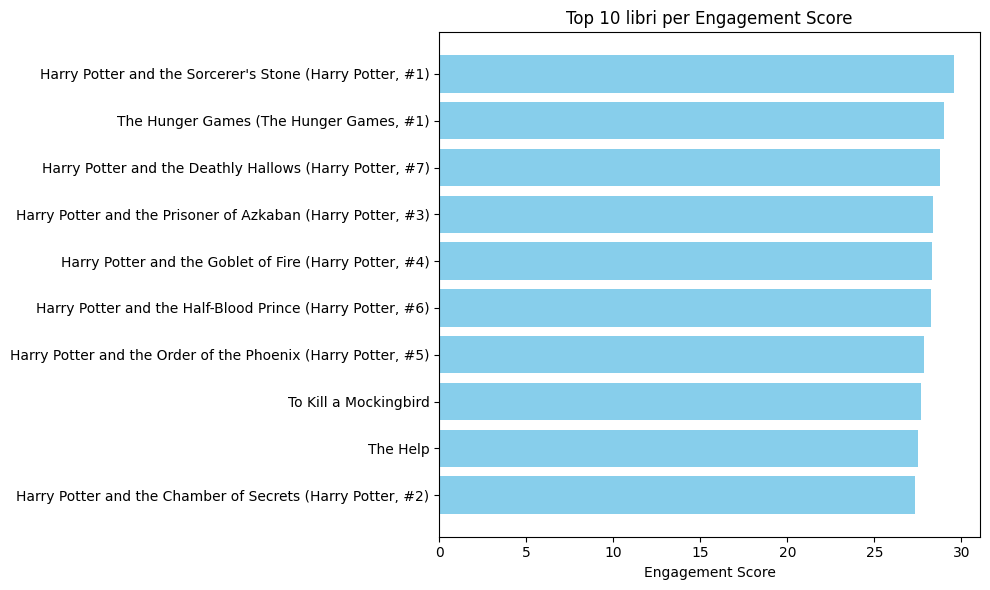

In [21]:
# PUNTO 4. Grafico a barre: top 10 libri per engagement_score
top10 = df.nlargest(10, 'engagement_score')
plt.figure(figsize=(10,6))
plt.barh(top10['title'], top10['engagement_score'], color='skyblue')
plt.xlabel('Engagement Score')
plt.title('Top 10 libri per Engagement Score')
plt.gca().invert_yaxis()  # per avere il più alto in alto
plt.tight_layout()
plt.show()

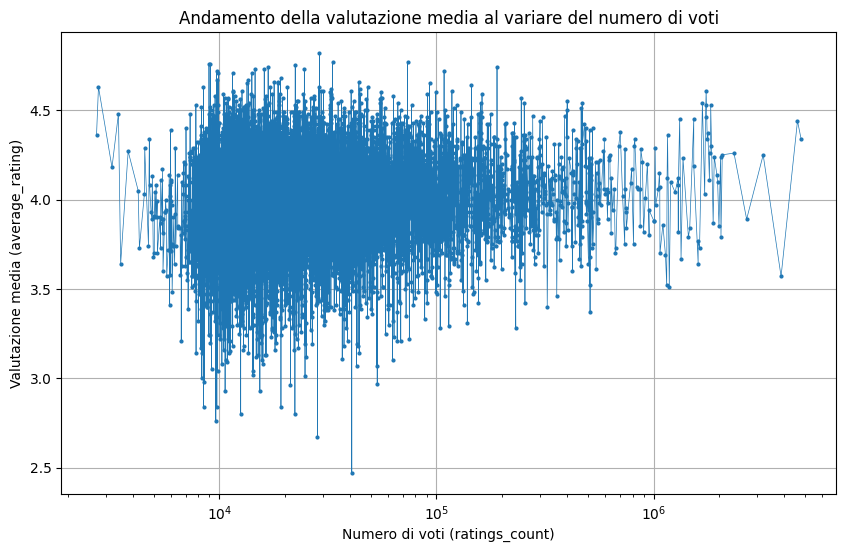

In [22]:
# PUNTO 5. Grafico a linee: average_rating ordinato per ratings_count crescente
df_sorted = df.sort_values('ratings_count')
plt.figure(figsize=(10,6))
plt.plot(df_sorted['ratings_count'], df_sorted['average_rating'], 'o-', markersize=2, linewidth=0.5)
plt.xlabel('Numero di voti (ratings_count)')
plt.ylabel('Valutazione media (average_rating)')
plt.title('Andamento della valutazione media al variare del numero di voti')
plt.xscale('log')  # per visualizzare meglio su scala logaritmica (opzionale)
plt.grid(True)
plt.show()

## Esercizio 5
Utilizza il dataset `adult.csv`.
Contiene informazioni demografiche su adulti negli Stati Uniti. Le colonne rilevanti sono:
- `age`: età (integer)
- `workclass`, `education`, `marital-status`, `occupation`, `race`, `sex`
- `hours-per-week`: ore lavorate a settimana
- `income`: `>50K` o `<=50K` (target)

1. Quante **righe e colonne** ha il dataset?
2. Quanti **valori mancanti** ci sono per colonna?
3. **Sostituisci i valori mancanti** nelle colonne categoriche (workclass, occupation, native-country) con il valore più frequente (la moda).
4. Calcola l’**età media** (`age`) per sesso (`sex`)
5. Trova la % di persone che guadagnano **>50K** per sesso.
7. Crea una **colonna `age_group`** raggruppando le età in fasce: `'<30'`, `'30-50'`, `'>50'`.
8. **Crea**:
   - un grafico **a barre** con % di reddito `>50K` per fascia di età.
   - un **boxplot** delle ore lavorate (`hours-per-week`) per gruppo reddito (<=50, >50).


#### LEGGENDA

- **pd.read_csv('file.csv', na_values='?')** -> Carica il CSV, interpreta '?' come NaN

- **df.shape** -> Restituisce (righe, colonne)

- **df.isnull().sum()** -> Conta i NaN per colonna

- **df[col].mode()[0]** -> Calcola la moda (valore più frequente) di una colonna

- **df[col].fillna(moda)** -> Sostituisce i NaN con la moda

- **df.groupby('sex')['age'].mean()** -> Media dell'età per sesso

- **df['income'].str.strip() == '>50K'** -> Maschera booleana (True se reddito >50K)

- **.astype(int)** -> Trasforma True/False in 1/0

- **df.groupby('sex')['is_rich'].mean() * 100** -> Percentuale di ricchi per sesso

- **pd.cut(df['age'], bins=[0,30,50,100], labels=['<30','30-50','>50'])** -> Crea fasce d'età

- **df.groupby('age_group', observed=True)['is_rich'].mean() * 100** -> Percentuale di ricchi per fascia (observed=True evita warning)

- **.plot(kind='bar')** -> Grafico a barre

- **sns.boxplot(x='income', y='hours_per_week', data=df)** -> Boxplot delle ore per reddito

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PUNTO 1. Righe e colonne del dataset
df = pd.read_csv('adult_con_titoli.csv', na_values='?')
print("1. DATASET CARICATO","\n")
print(f"Numero di righe: {df.shape[0]}", "\n")
print(f"Numero di colonne: {df.shape[1]}", "\n")
print(f"Prime 2 righe:\n{df.head(2)}")

1. DATASET CARICATO 

Numero di righe: 32561 

Numero di colonne: 15 

Prime 2 righe:
   age          workclass  fnlwgt   education  education-num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   

        marital-status        occupation    relationship    race    sex  \
0        Never-married      Adm-clerical   Not-in-family   White   Male   
1   Married-civ-spouse   Exec-managerial         Husband   White   Male   

   capital-gain  capital-loss  hours-per-week  native-country  income  
0          2174             0              40   United-States   <=50K  
1             0             0              13   United-States   <=50K  


In [80]:
# PUNTO 2. Conteggio dei valori mancanti
print("\n2. VALORI MANCANTI (prima della pulizia)")
mancanti = df.isnull().sum()
if (mancanti > 0).any():
    print(mancanti[mancanti > 0])
else:
    print("Nessun valore mancante trovato.")


2. VALORI MANCANTI (prima della pulizia)
Nessun valore mancante trovato.


In [82]:
# PUNTO 3. Sostituisco i valori mancanti con la moda
colonne_da_pulire = ['workclass', 'occupation', 'native-country']

print("\n3. PULIZIA DEI VALORI MANCANTI")
for col in colonne_da_pulire:
    
    moda = df[col].mode()[0]            # Calcolo la moda
    df[col] = df[col].fillna(moda)      # Sostituisco
    
    print(f"{col}: moda '{moda}', NaN rimasti {df[col].isnull().sum()}")


3. PULIZIA DEI VALORI MANCANTI
workclass: moda ' Private', NaN rimasti 0
occupation: moda ' Prof-specialty', NaN rimasti 0
native-country: moda ' United-States', NaN rimasti 0


In [84]:
# PUNTO 4. Età media per sesso

print("\n4. ETÀ MEDIA PER SESSO")
eta_media = df.groupby('sex')['age'].mean()
for sesso, media in eta_media.items():
    print(f"{sesso}: {media:.1f} anni")


4. ETÀ MEDIA PER SESSO
 Female: 36.9 anni
 Male: 39.4 anni


In [85]:
# PUNTO 5. Percentuale di persone che guadagnano >50K per sesso
df['is_rich'] = (df['income'].str.strip() == '>50K').astype(int)    # Creo una colonna di comodo: 1 se guadagna >50k, 0 altrimenti
                                                                    # Uso .str.strip() per rimuovere eventuali spazi
print("\n5. PERCENTUALE CON REDDITO >50K PER SESSO")
perc_ricchi = df.groupby('sex')['is_rich'].mean() * 100
for sesso, perc in perc_ricchi.items():
    print(f"{sesso}: {perc:.2f}%")


5. PERCENTUALE CON REDDITO >50K PER SESSO
 Female: 10.95%
 Male: 30.57%


In [86]:
# PUNTO 6. Creo le fasce d'età (age_group)
bins = [0, 30, 50, 100]                     # limiti delle fasce
labels = ['<30', '30-50', '>50']            # nomi delle fasce
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

print("\n6. DISTRIBUZIONE DELLE FASCE D'ETÀ")
print(df['age_group'].value_counts().sort_index())



6. DISTRIBUZIONE DELLE FASCE D'ETÀ
age_group
<30      10572
30-50    15529
>50       6460
Name: count, dtype: int64


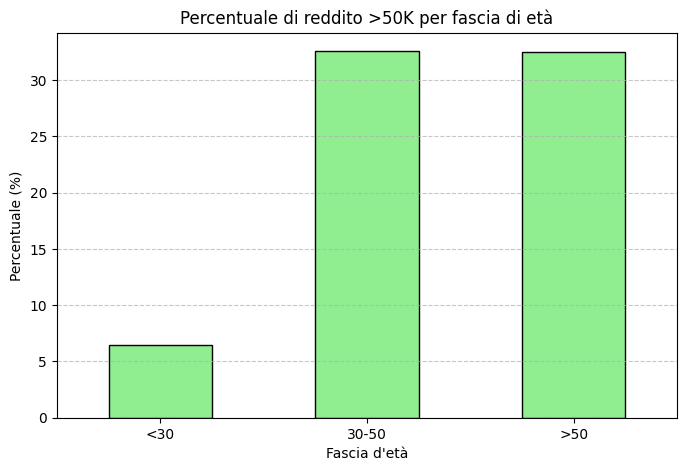

In [68]:
# PUNTO 7. Grafico a barre: % di reddito >50K per fascia d'età

rich_by_age = df.groupby('age_group', observed=True)['is_rich'].mean() * 100

plt.figure(figsize=(8,5))
rich_by_age.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Percentuale di reddito >50K per fascia di età')
plt.ylabel('Percentuale (%)')
plt.xlabel('Fascia d\'età')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\kokin\AppData\Local\Temp\ipykernel_16456\1743469677.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income', y='hours-per-week', palette='Set2')


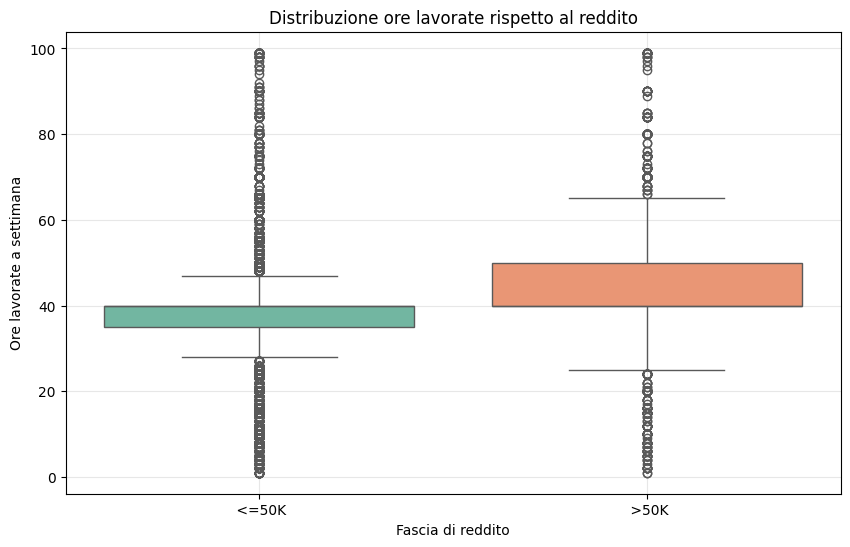

In [72]:
# PUNTO 8. Boxplot: ore lavorate a settimana per gruppo reddito (<=50K vs >50K)

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='income', y='hours-per-week', palette='Set2')
plt.title('Distribuzione ore lavorate rispetto al reddito')
plt.xlabel('Fascia di reddito')
plt.ylabel('Ore lavorate a settimana')
plt.grid(True, alpha=0.3)
plt.show()

## Esercizio 6

Genera due array:

`x = np.linspace(0, 5, 80)`  
`y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)`

1. Usa `scipy.optimize.curve_fit` per stimare i parametri della retta.
2. Plotta i punti originali e la retta ottenuta.
3. Calcola MAE e RMSE tra i valori reali e quelli stimati.

#### LEGGENDA

- **np.linspace(0, 5, 80)** -> Crea 80 punti equidistanti tra 0 e 5

- **np.random.normal(0, 0.5, 80)** -> Genera 80 errori casuali con distribuzione normale (media 0, deviazione standard 0.5)

- **def modello(x, a, b): return a*x + b** -> Definisce la funzione lineare da adattare

- **scipy.optimize.curve_fit(modello, x, y)** -> Trova i parametri ottimali (a, b) che minimizzano l'errore

- **plt.scatter(x, y)** -> Grafico a punti (dati originali)

- **plt.plot(x, y_pred, 'r-')** -> Grafico della retta stimata

- **np.abs(y - y_pred).mean()** -> MAE (errore medio assoluto)

- **np.sqrt(((y - y_pred)**2).mean())** -> RMSE (radice dell'errore quadratico medio)

1. DATI GENERATI
Primi 5 x: [0.         0.06329114 0.12658228 0.18987342 0.25316456]
Primi 5 y: [1.44835708 1.2890957  1.84029997 2.43619847 1.71583471]

2. PARAMETRI STIMATI
a (coefficiente angolare): 2.5095
b (intercetta): 1.1144

3. ERRORI
MAE (Mean Absolute Error): 0.3789
RMSE (Root Mean Square Error): 0.4755


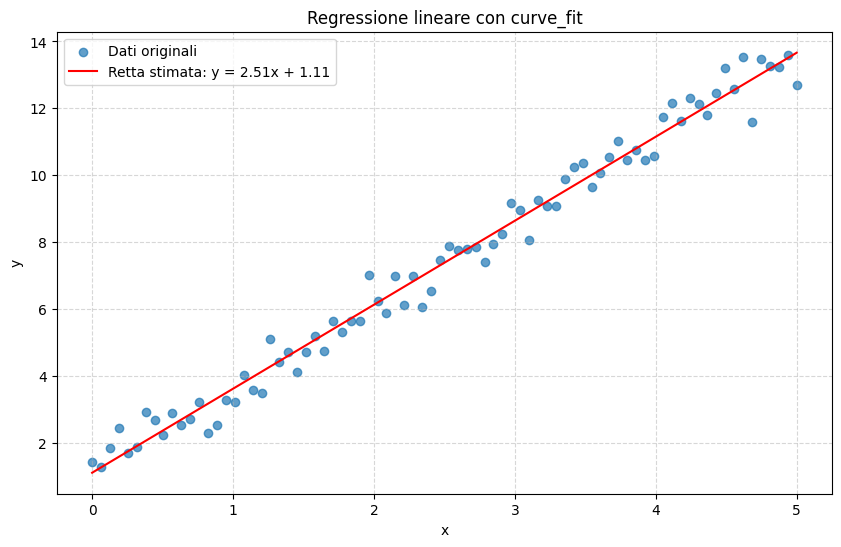

In [87]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Genero i dati
np.random.seed(42)  # per riproducibilità
x = np.linspace(0, 5, 80)
y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)

print("1. DATI GENERATI")
print(f"Primi 5 x: {x[:5]}")
print(f"Primi 5 y: {y[:5]}")

# 2. Definisco il modello lineare
def modello(x, a, b):
    return a * x + b

# 3. Uso curve_fit per stimare i parametri
params, cov = curve_fit(modello, x, y)
a, b = params
print("\n2. PARAMETRI STIMATI")
print(f"a (coefficiente angolare): {a:.4f}")
print(f"b (intercetta): {b:.4f}")

# 4. Calcolo i valori stimati dalla retta
y_pred = modello(x, a, b)

# 5. Calcolo MAE e RMSE
mae = np.abs(y - y_pred).mean()
rmse = np.sqrt(((y - y_pred)**2).mean())
print("\n3. ERRORI")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (Root Mean Square Error): {rmse:.4f}")

# 6. Grafico: punti originali e retta stimata
plt.figure(figsize=(10,6))
plt.scatter(x, y, label='Dati originali', alpha=0.7)
plt.plot(x, y_pred, 'r-', label=f'Retta stimata: y = {a:.2f}x + {b:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressione lineare con curve_fit')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()